In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
def step(x):
    return 1 if x >= 0 else 0

In [5]:
def plot_boundary(X, y, w, b, title, ax):
    for i in range(len(X)):
        if y[i] == 1:
            ax.scatter(X[i][0], X[i][1], color='blue', s=100)
        else:
            ax.scatter(X[i][0], X[i][1], color='red', s=100)
    x_vals = np.linspace(-0.5, 1.5, 100)
    if np.linalg.norm(w) > 1e-6:
        if abs(w[1]) > 1e-6:
            y_vals = -(w[0]*x_vals + b)/w[1]
            ax.plot(x_vals, y_vals, 'k')
        elif abs(w[0]) > 1e-6:
            ax.axvline(-b/w[0], color='k')
    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)
    ax.grid(True)
    ax.set_title(title)

In [6]:
def perceptron(X, y, lr=1, epochs=10, gate="Gate"):
    w = np.zeros(X.shape[1])
    b = 0
    all_updates = []
    update_count = 0
    print("\n==============================")
    print(gate)
    print("==============================")
    for epoch in range(epochs):
        error_count = 0
        for i in range(len(X)):
            net = np.dot(X[i], w) + b
            pred = step(net)
            error = y[i] - pred
            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error
                update_count += 1
                all_updates.append((w.copy(), b, update_count))
                error_count += 1
        if error_count == 0:
            print("\nTraining Completed!")
            break
    print("\nFinal Weights:", w)
    print("Final Bias:", b)
    num_plots = len(all_updates)
    if num_plots > 0:
        cols = 3
        rows = (num_plots + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()
        for idx, (updated_w, updated_b, update_num) in enumerate(all_updates):
            plot_boundary(X, y, updated_w, updated_b, f"{gate} - Update {update_num}", axes[idx])
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        plt.tight_layout()
        plt.savefig(f'{gate.lower().replace(" ", "_")}_updates.pdf', dpi=600, format='pdf')

### AND Gate Perceptron


AND Gate

Training Completed!

Final Weights: [2. 1.]
Final Bias: -3


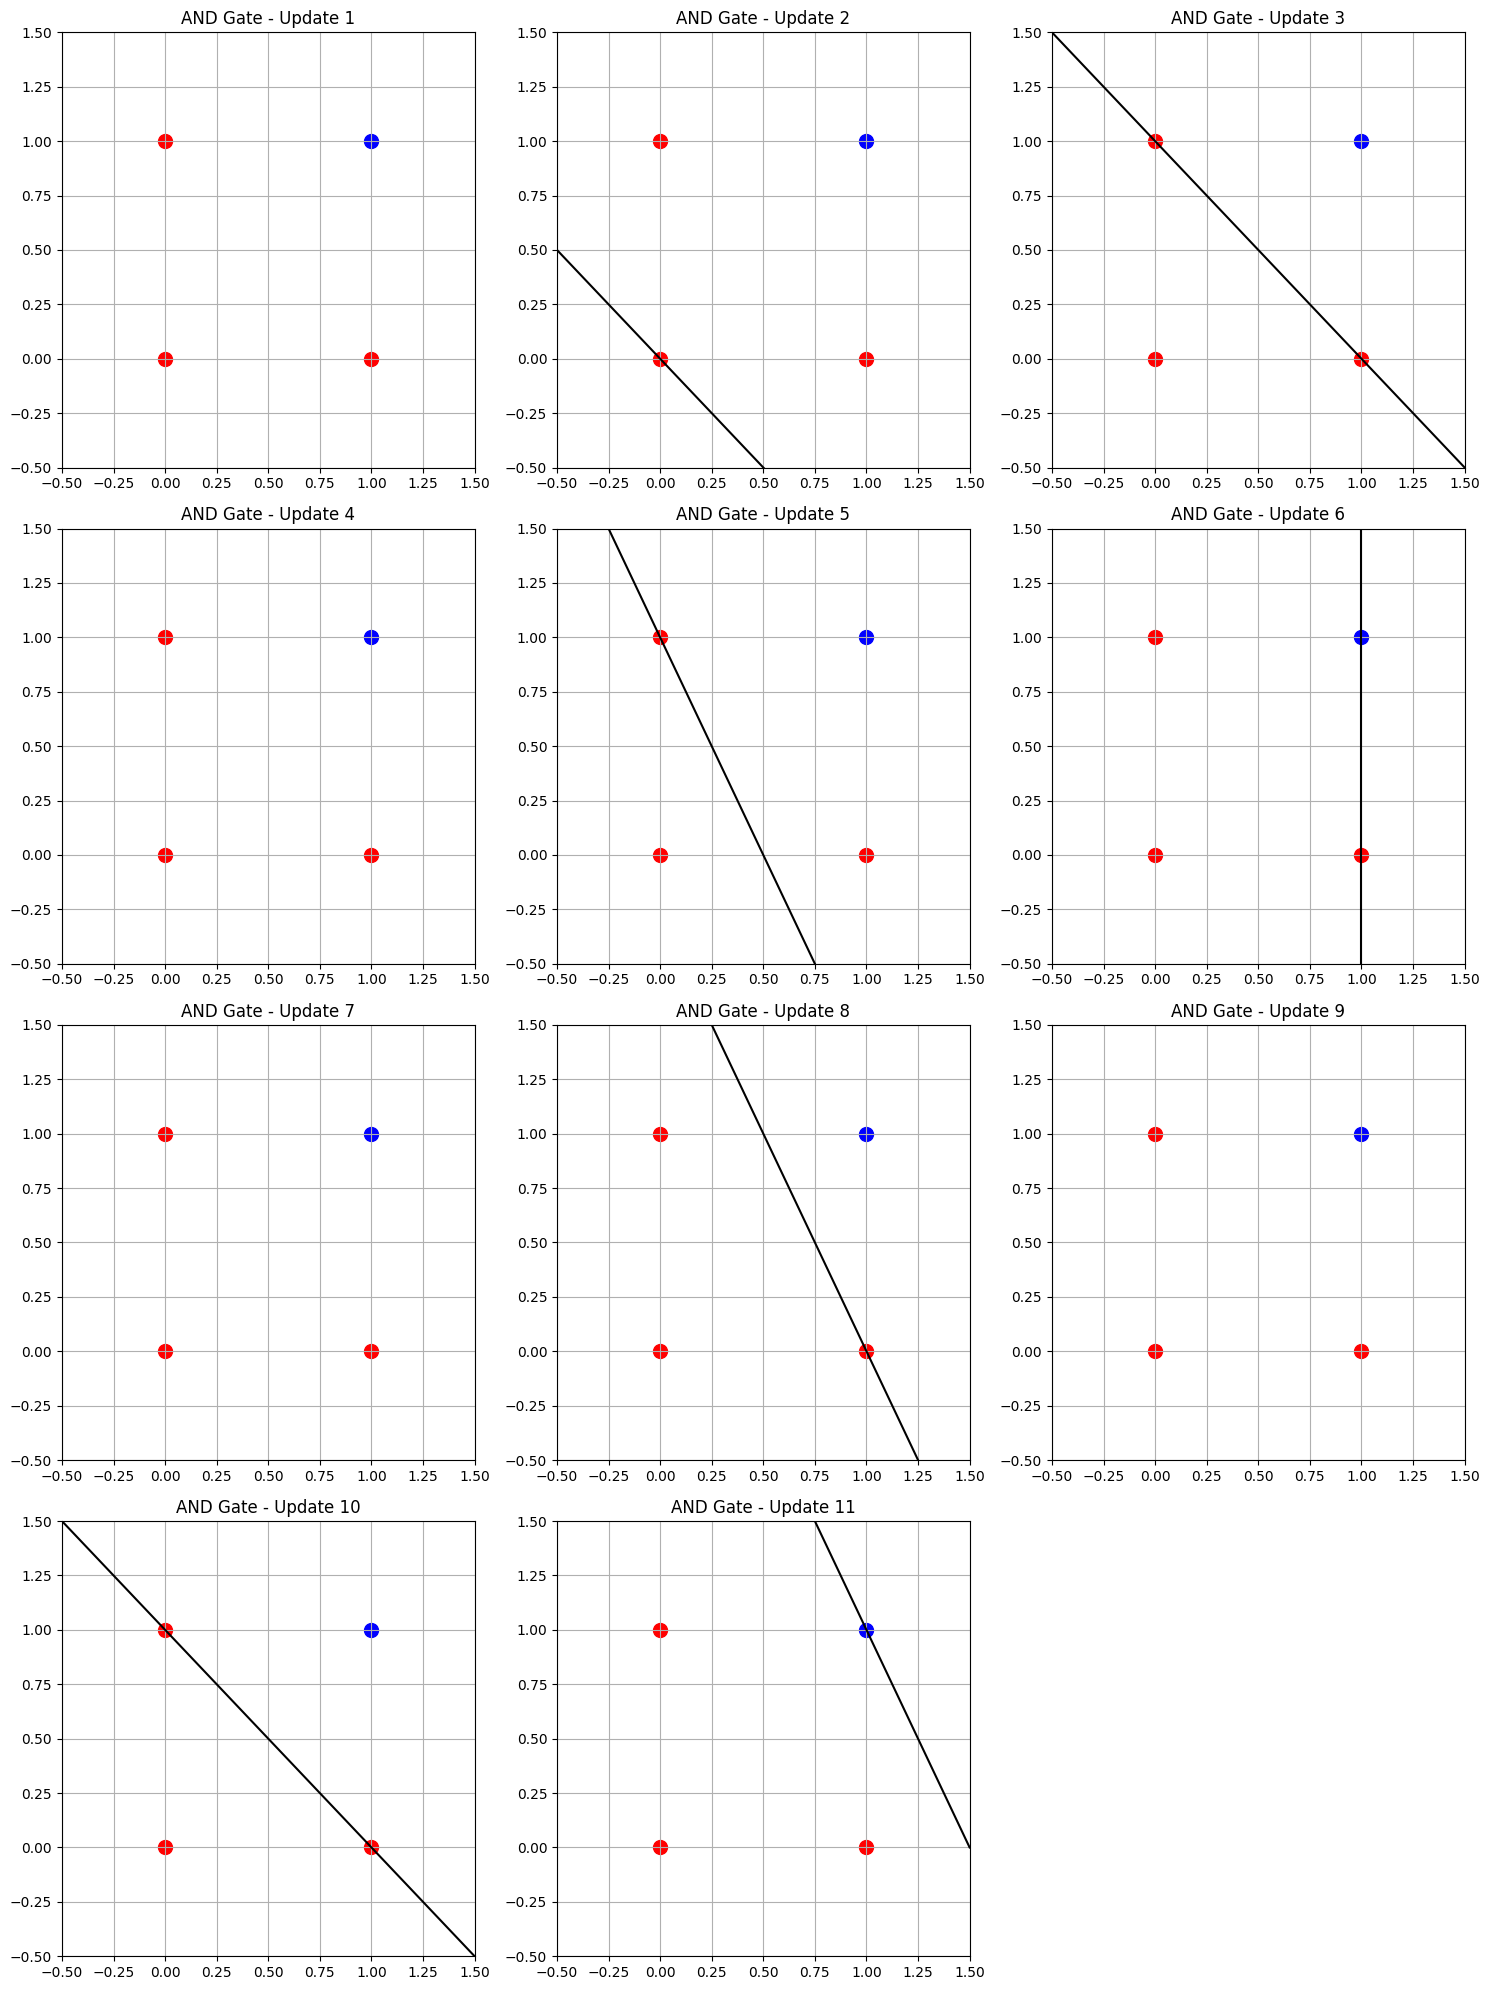

In [7]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

perceptron(X_and, y_and, gate="AND Gate")

### OR Gate Perceptron


OR Gate

Training Completed!

Final Weights: [1. 1.]
Final Bias: -1


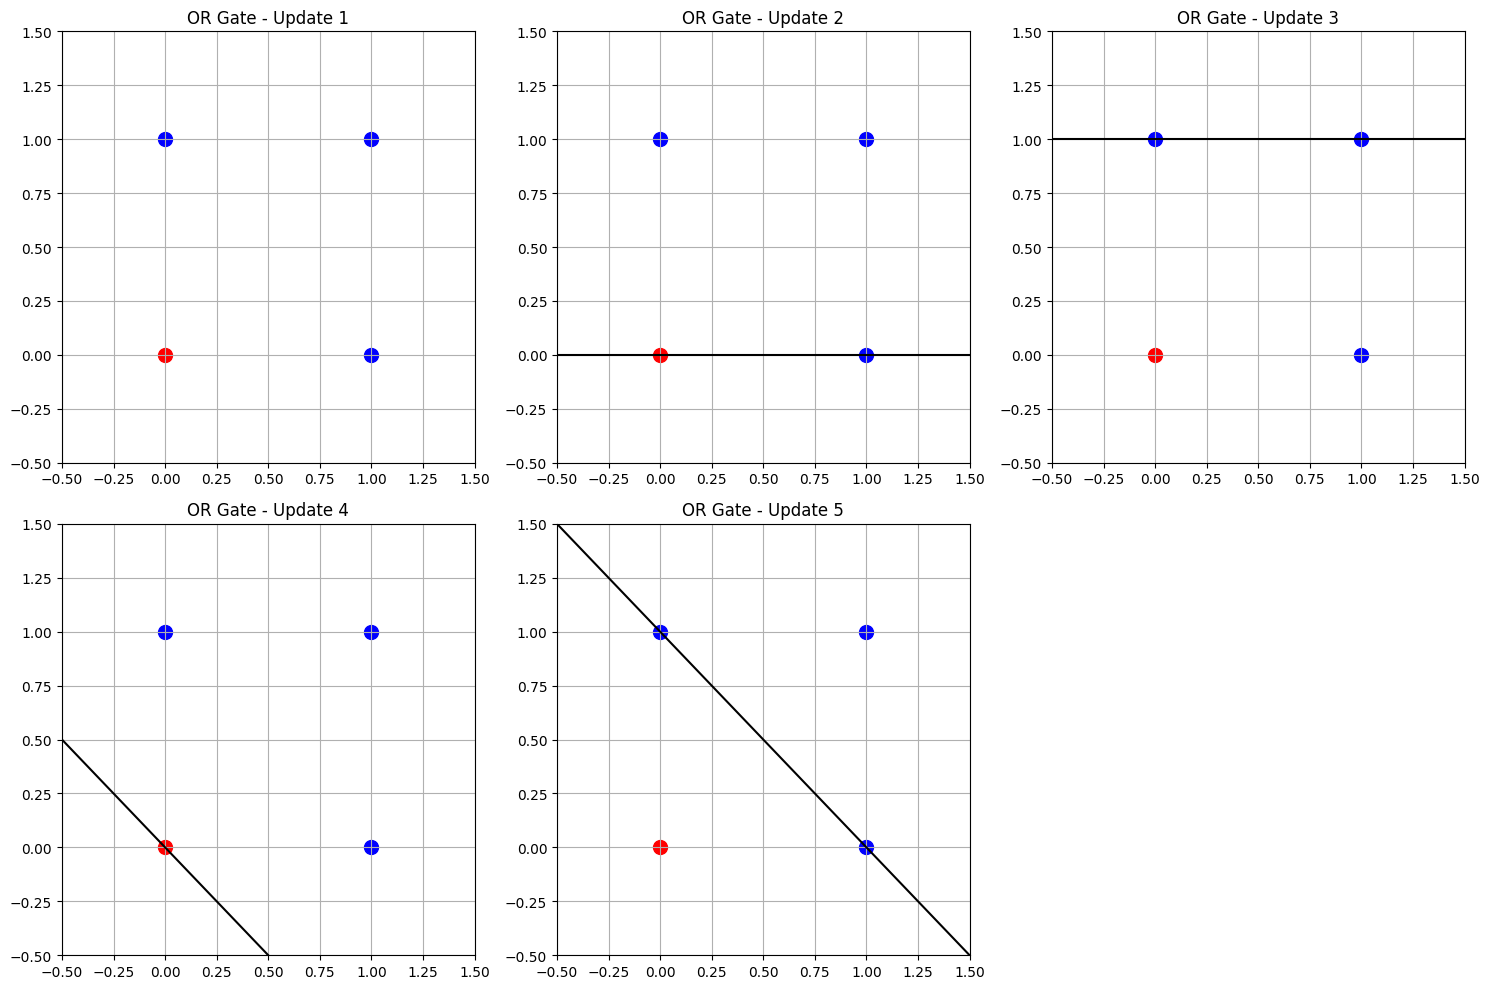

In [8]:
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

perceptron(X_or, y_or, gate="OR Gate")

### NOT Gate Perceptron

In [9]:
X_not = np.array([
    [0],
    [1]
])

y_not = np.array([1,0])

In [10]:
def plot_not(X, y, w, b, title, ax):
    for i in range(len(X)):
        if y[i]==1:
            ax.scatter(X[i],0,color='blue',s=100)
        else:
            ax.scatter(X[i],0,color='red',s=100)
    boundary = -b/w[0]
    ax.axvline(boundary,color='black')
    ax.set_xlim(-0.5,1.5)
    ax.set_yticks([])
    ax.grid(True)
    ax.set_title(title)

In [11]:
def perceptron_not(X,y,lr=1,epochs=10):
    w=np.zeros(1)
    b=0
    all_updates = []
    update_count = 0
    print("\n==============================")
    print("NOT Gate")
    print("==============================")
    for epoch in range(epochs):
        errors=0
        for i in range(len(X)):
            pred=step(np.dot(X[i],w)+b)
            error=y[i]-pred
            if error!=0:
                w=w+lr*error*X[i]
                b=b+lr*error
                update_count += 1
                all_updates.append((w.copy(), b, update_count))
                errors+=1
        if errors==0:
            print("\nTraining Completed!")
            break
    print("\nFinal Weights:",w)
    print("Final Bias:",b)
    num_plots = len(all_updates)
    if num_plots > 0:
        cols = 3
        rows = (num_plots + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()
        for idx, (updated_w, updated_b, update_num) in enumerate(all_updates):
            plot_not(X, y, updated_w, updated_b, f"NOT Gate - Update {update_num}", axes[idx])
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        plt.tight_layout()
        plt.savefig('not_gate_updates.pdf', dpi=600, format='pdf')


NOT Gate

Training Completed!

Final Weights: [-1.]
Final Bias: 0


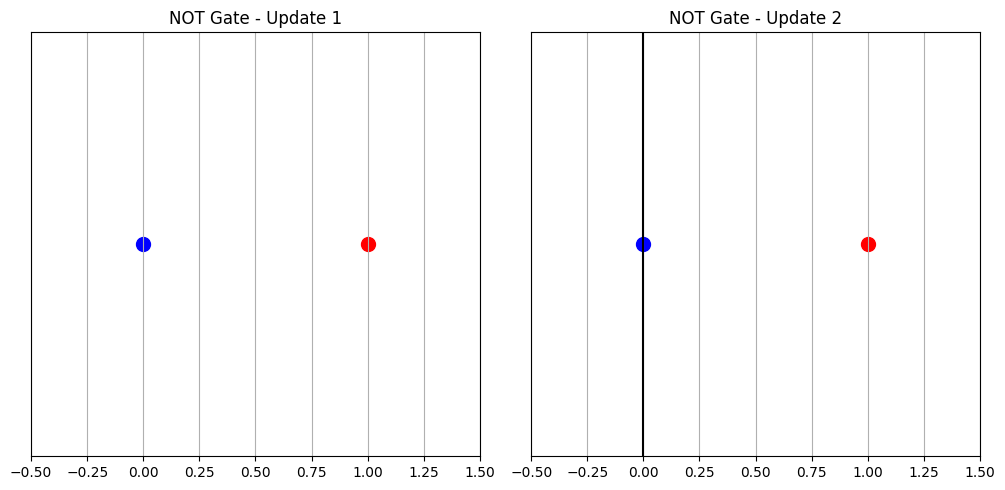

In [12]:
perceptron_not(X_not,y_not)